In [1]:
import jax.random as jrd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

## Simple replacement

In [2]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(1.0, name="scale")

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False

W0415 15:28:51.264519 25624665 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


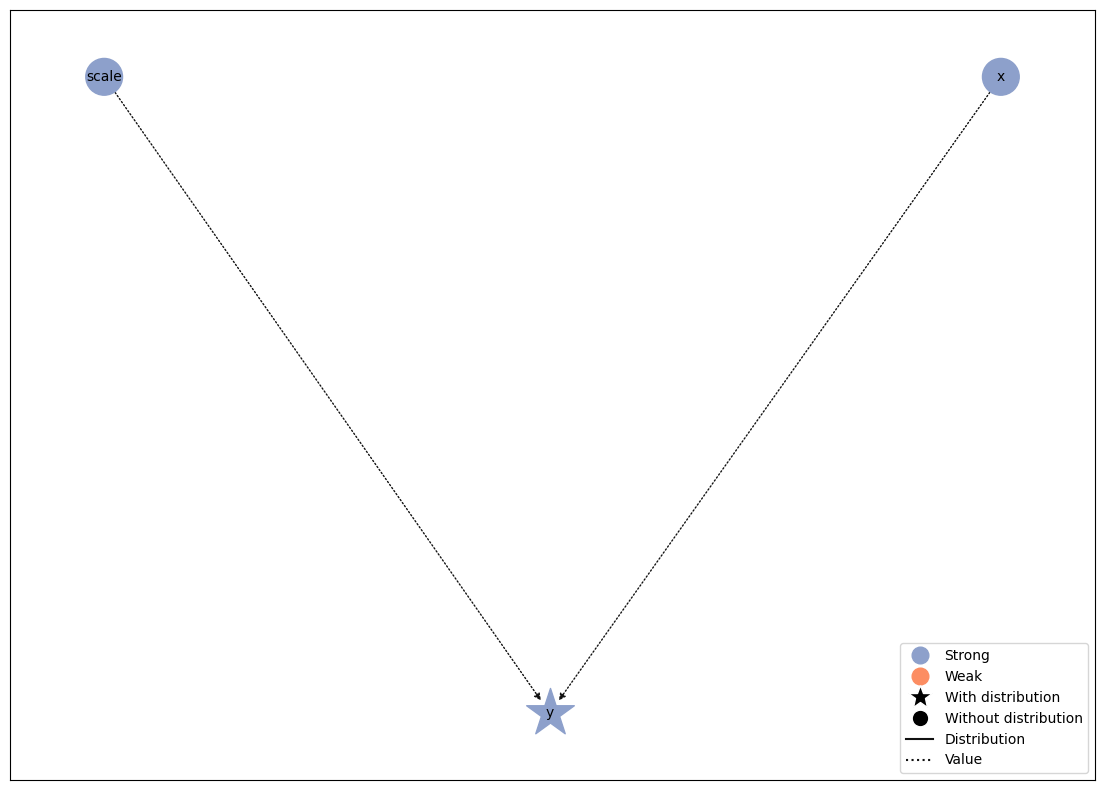

In [3]:
model.plot_vars()

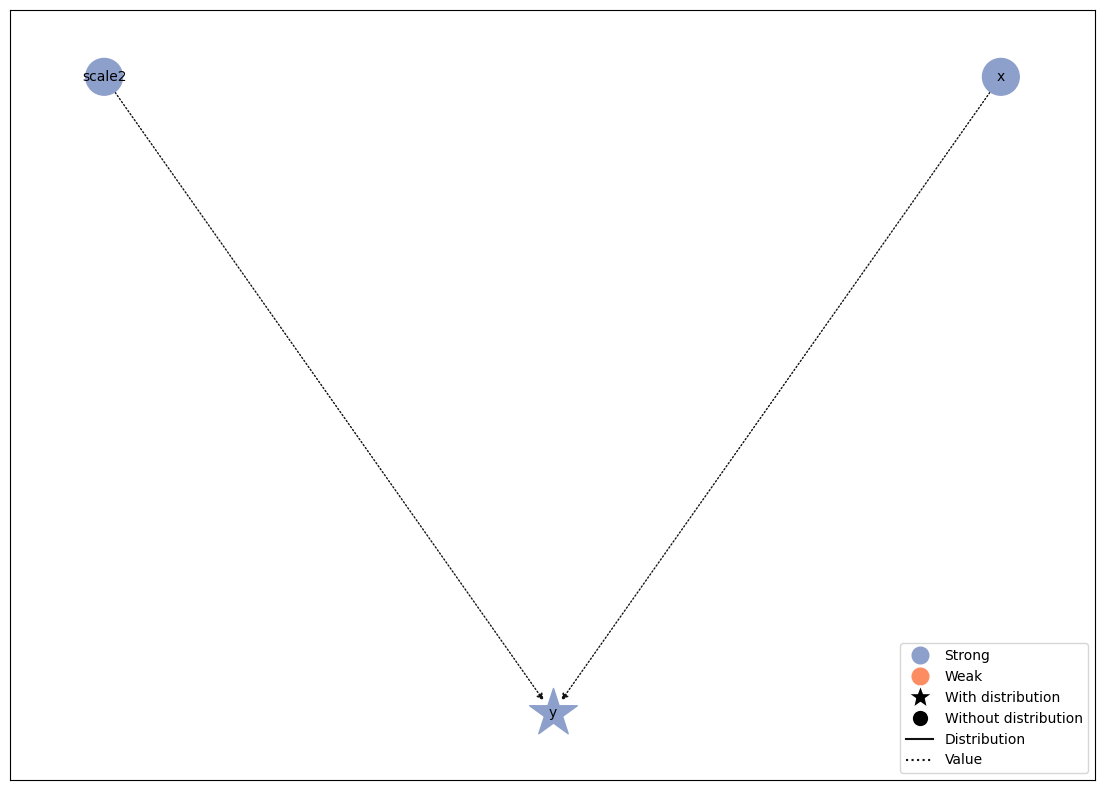

In [4]:
scale2 = lsl.Var.new_param(2.0, name="scale2")
model.replace("scale", scale2)
model.plot_vars()

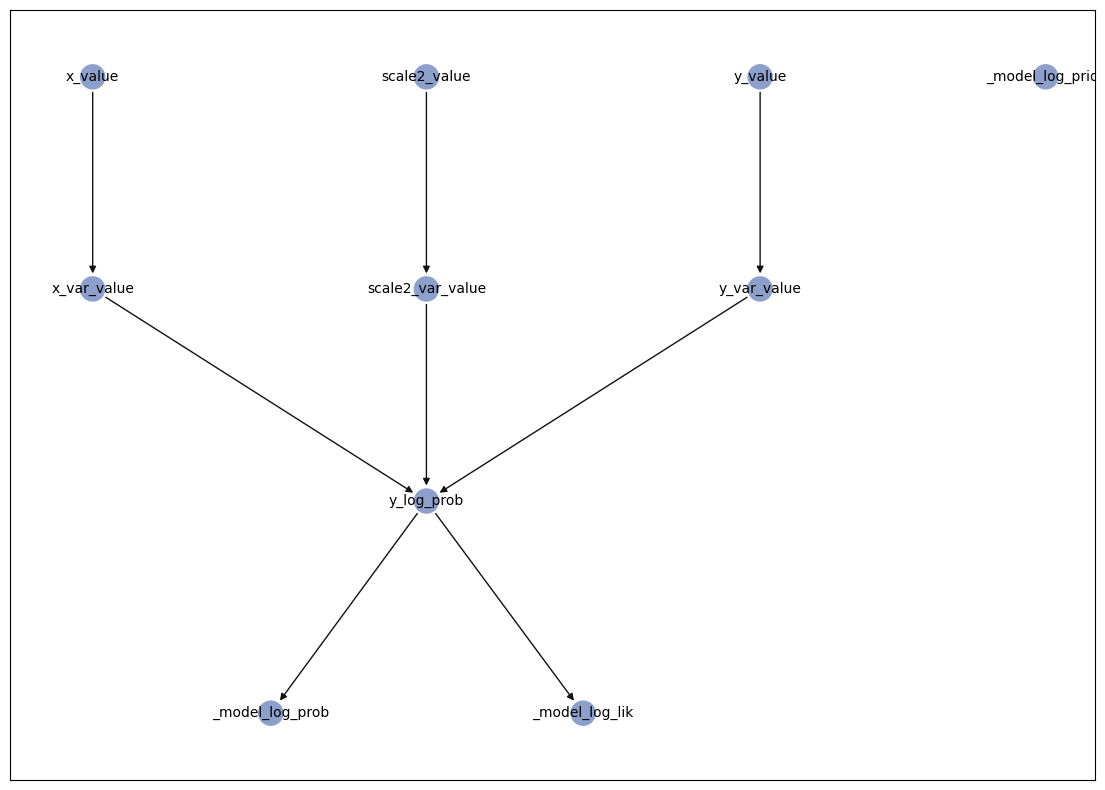

In [5]:
model.plot_nodes()

### Replace Var with Dist and hyperparameters

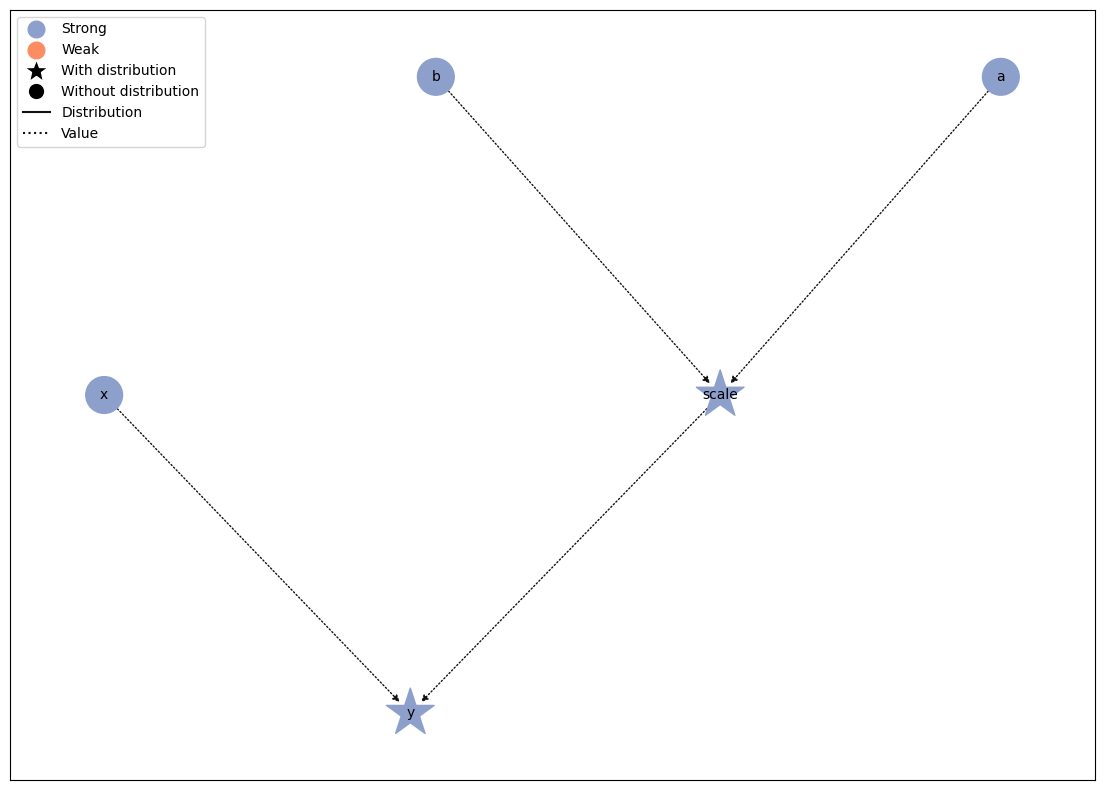

In [6]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

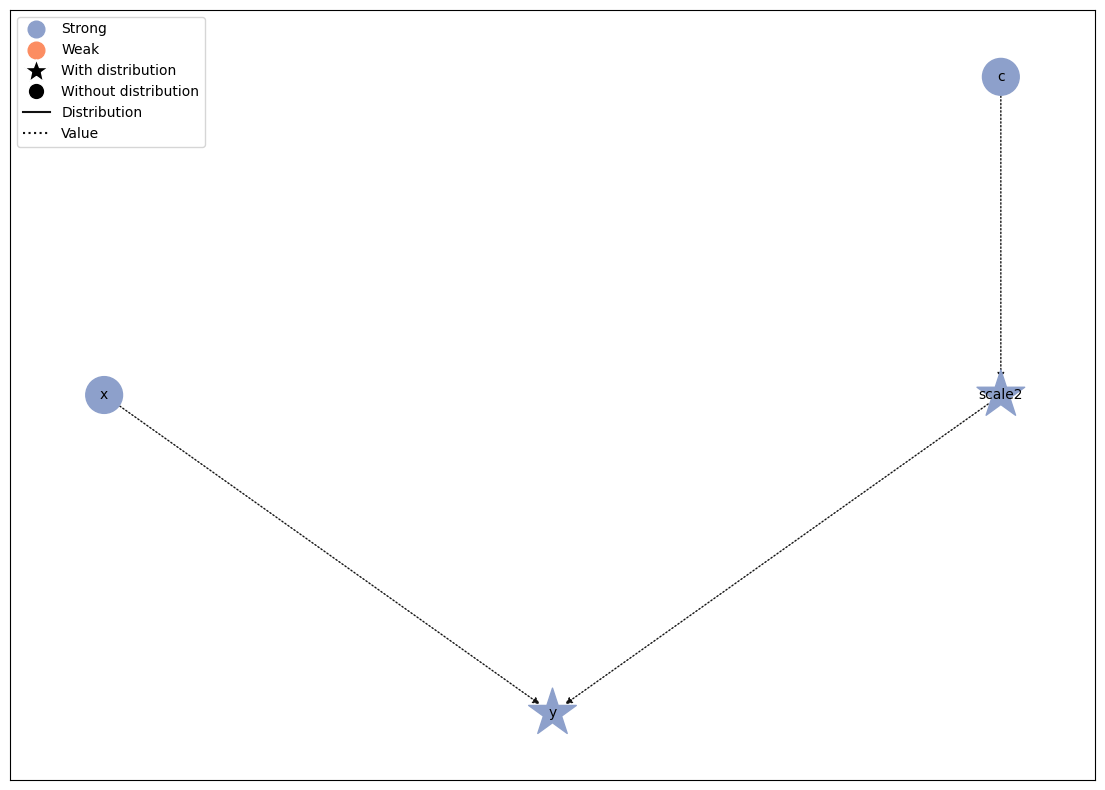

In [7]:
scale2 = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.Weibull,
        concentration=0.0,
        scale=lsl.Var.new_param(1.0, name="c"),
    ),
    name="scale2",
)

model.replace(scale, scale2)
model.plot_vars()

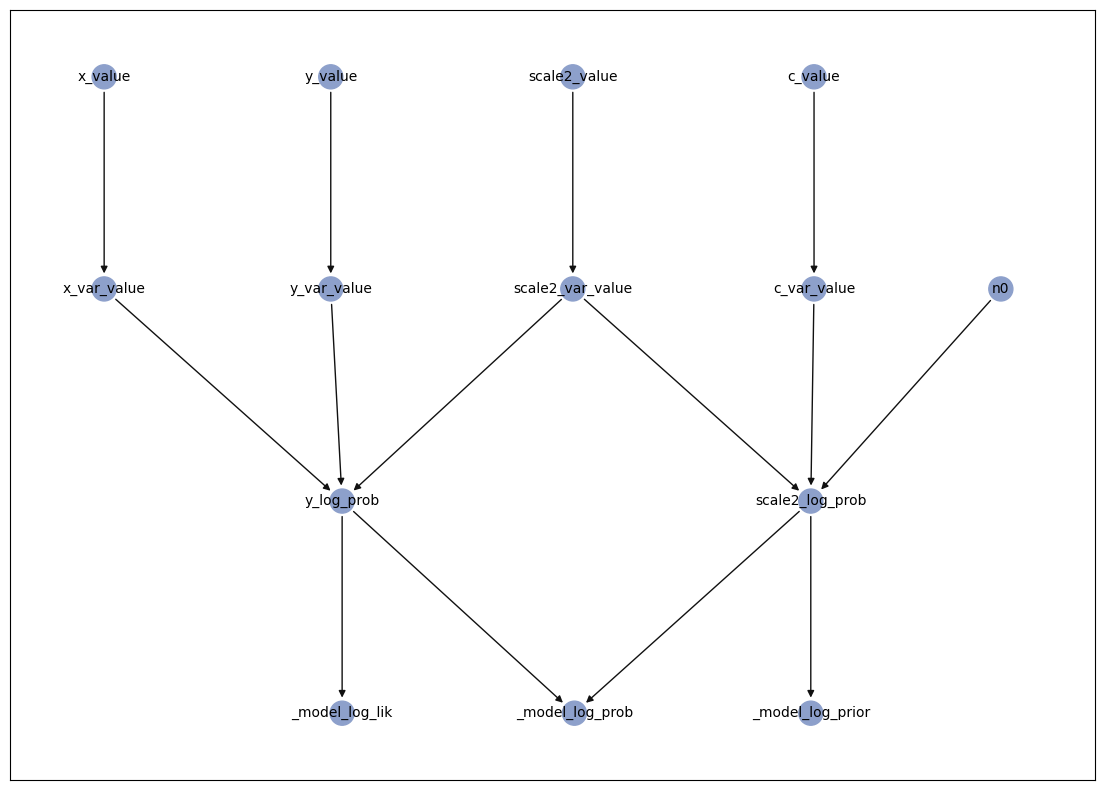

In [8]:
model.plot_nodes()

In [9]:
scale.model  # is now None

## Replace Var, creating a graph with two disconnected subgraphs

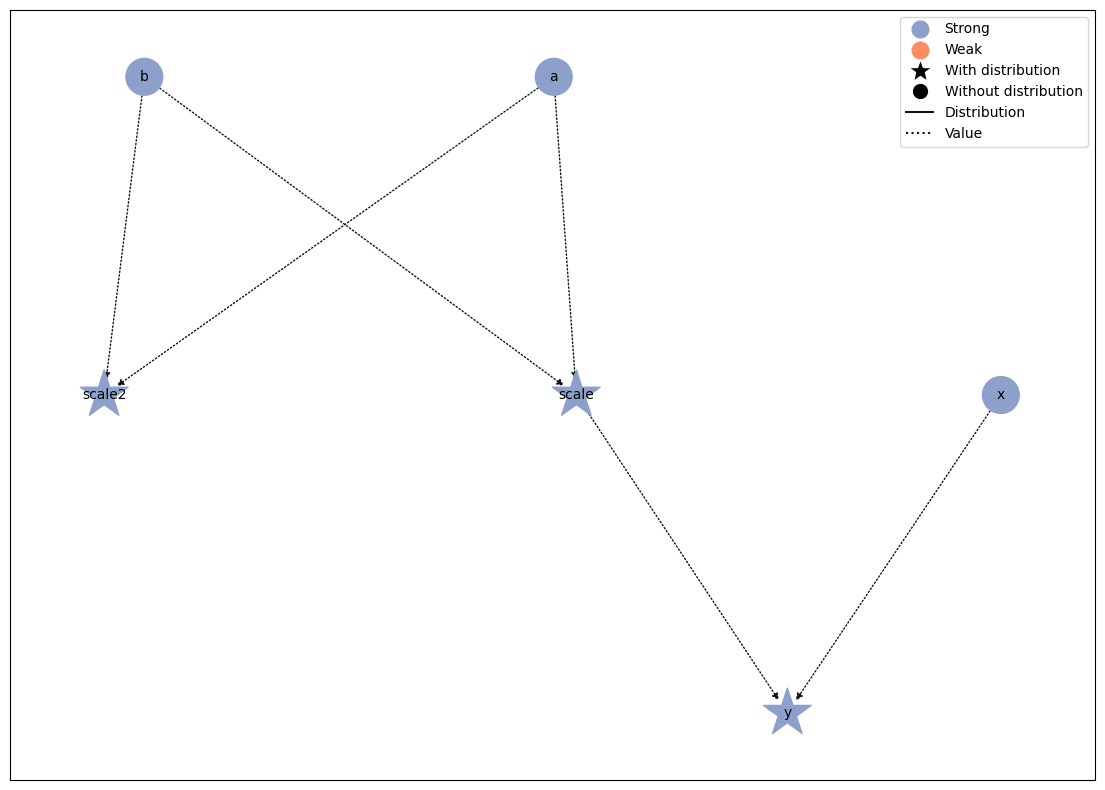

In [10]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

scale2 = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=scale.dist_node["concentration"],
        scale=scale.dist_node["scale"],
    ),
    name="scale2",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y, scale2])
model.locked = False
model.plot_vars()

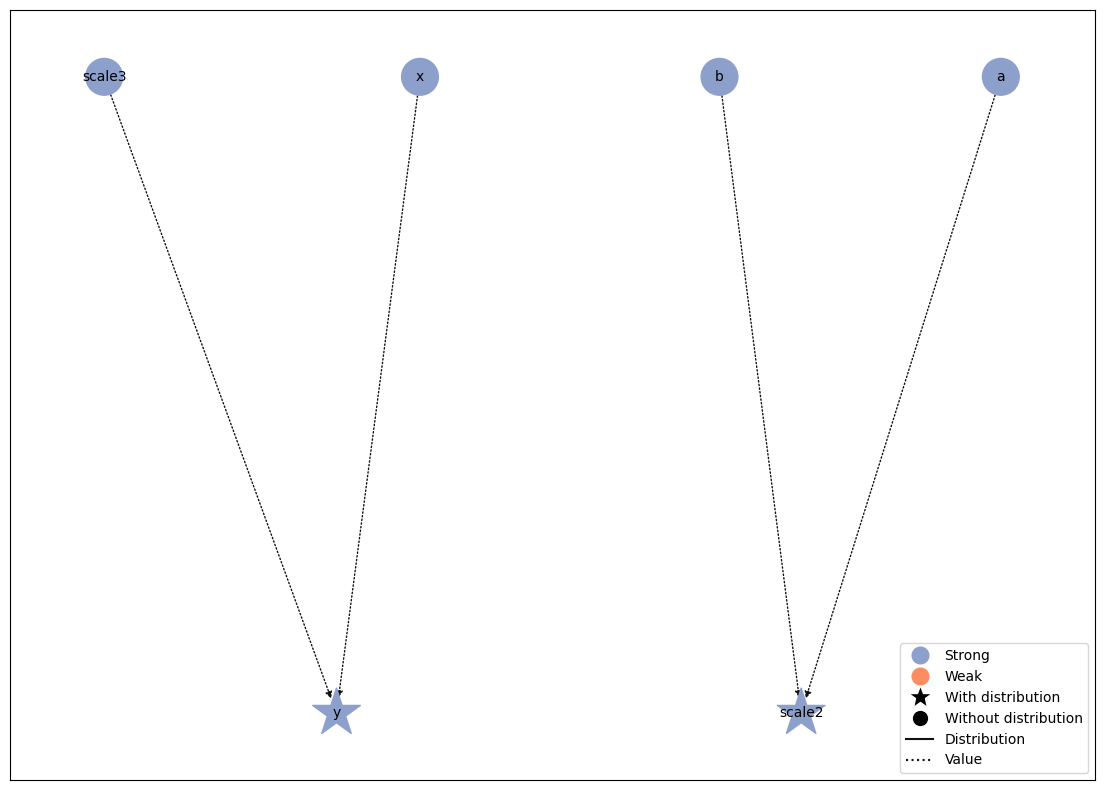

In [11]:
scale3 = lsl.Var.new_param(
    1.0,
    name="scale3",
)

model.replace(scale, scale3)
model.plot_vars()

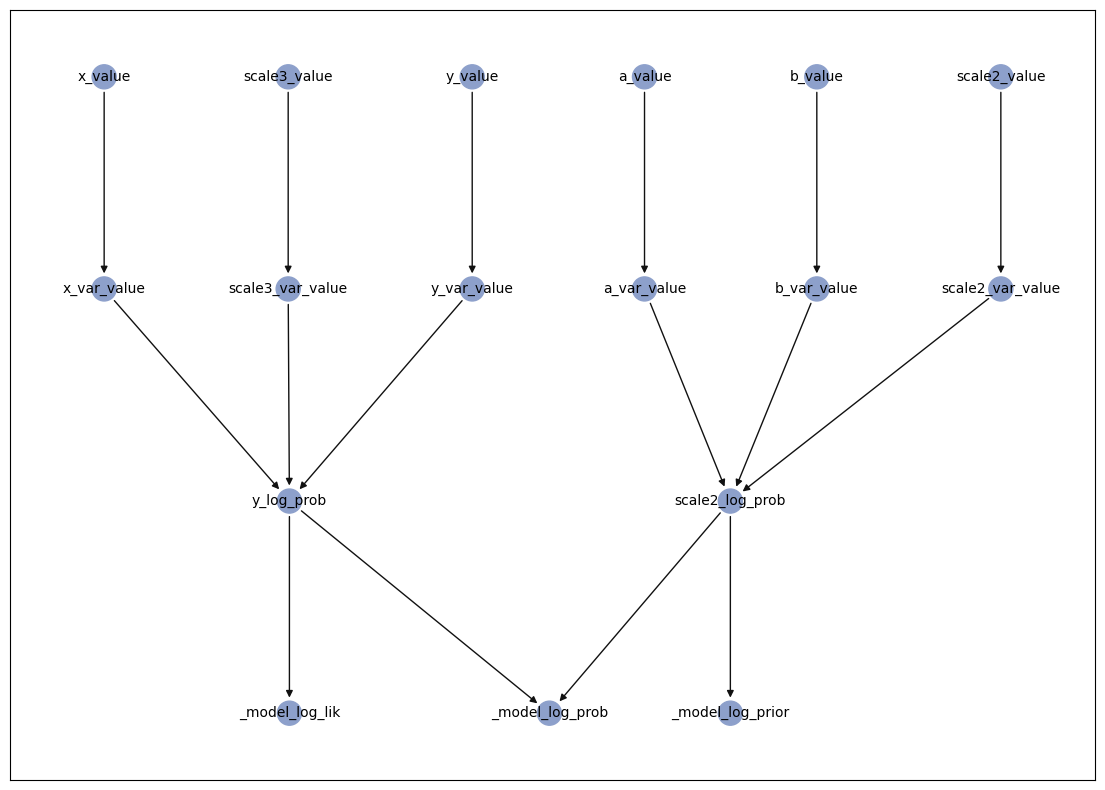

In [12]:
model.plot_nodes()

## Remove dist node

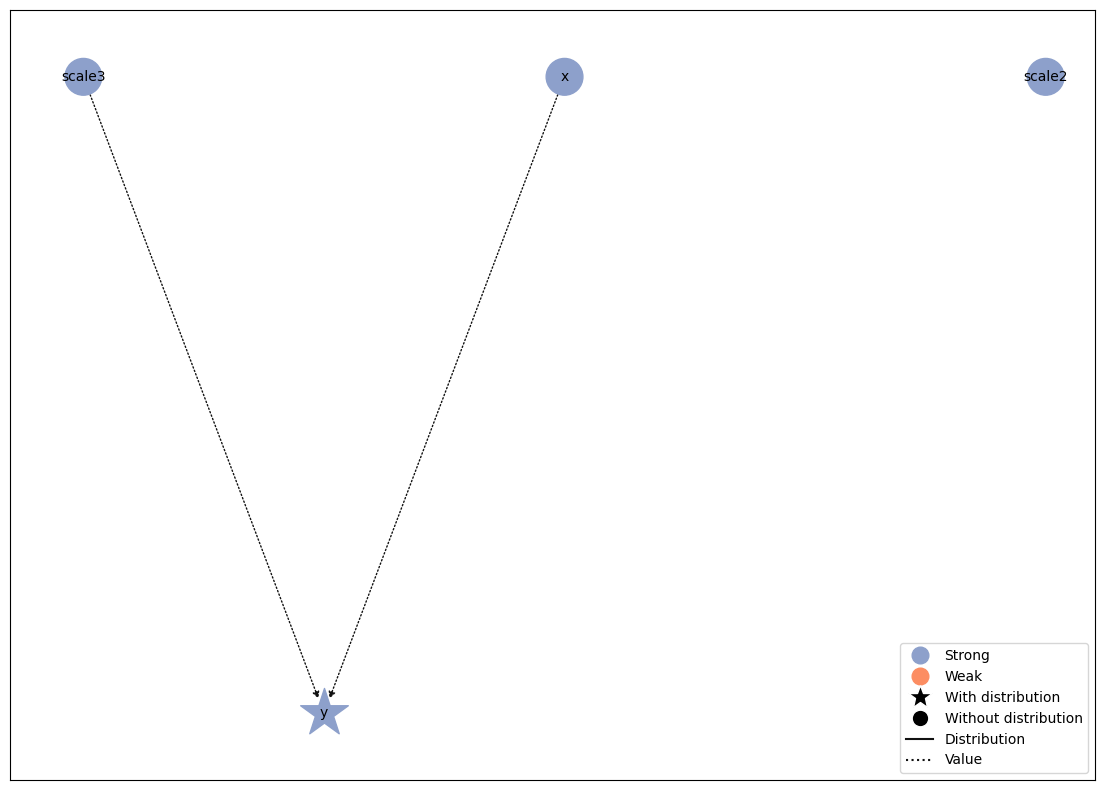

In [13]:
scale2.dist_node = None

model.plot_vars()

## Drop singletons

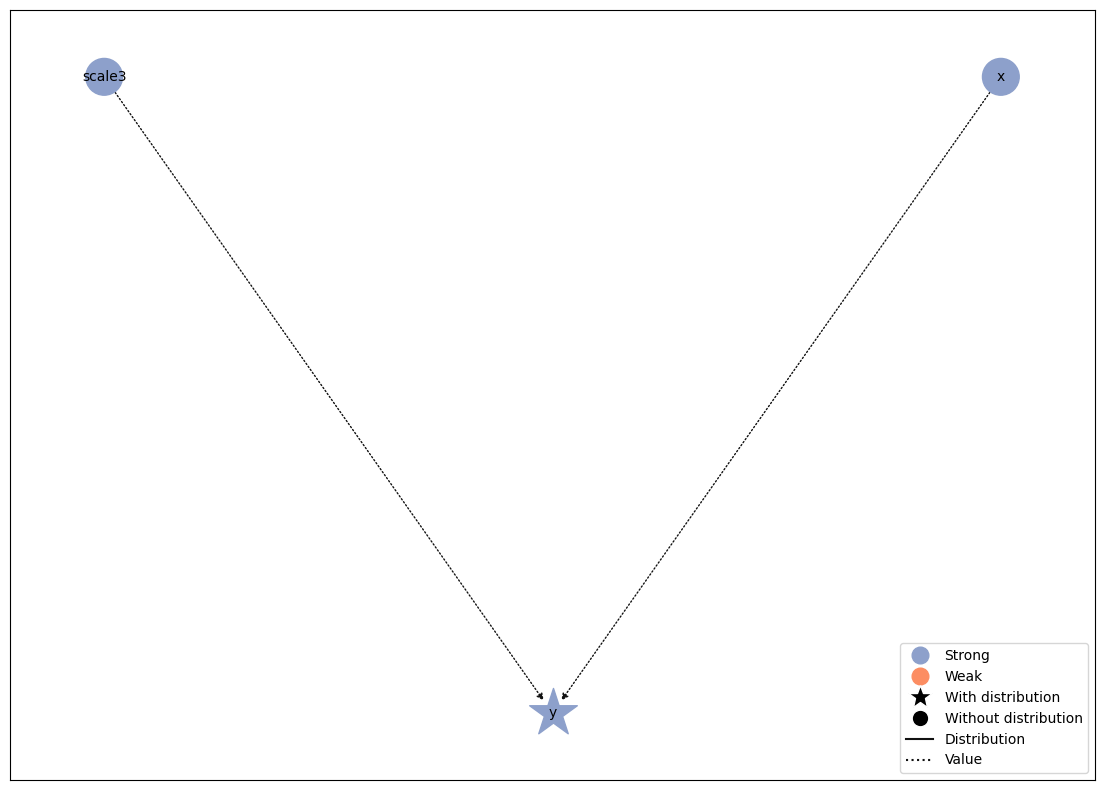

In [14]:
model.drop_singletons().plot_vars()

## Replace dist node

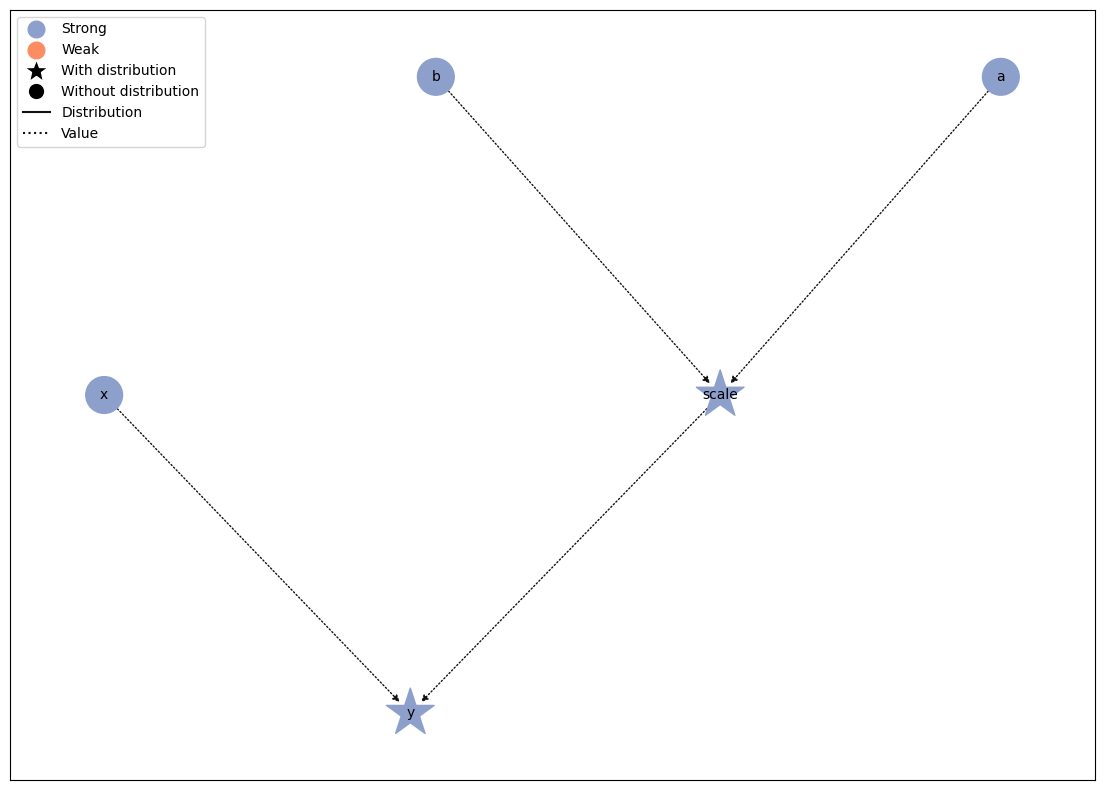

In [15]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

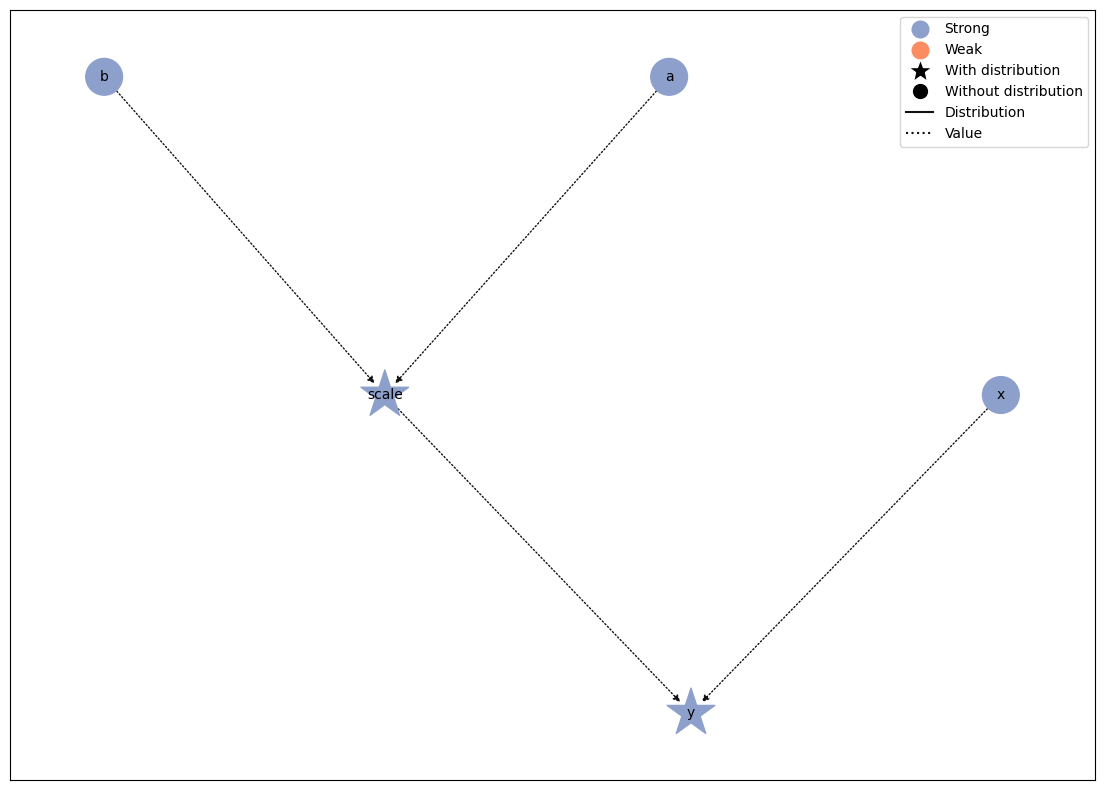

In [16]:
scale.dist_node = lsl.Dist(
    tfd.Weibull,
    concentration=lsl.Var.new_param(0.5, name="a"),
    scale=lsl.Var.new_param(2.0, name="b"),
)

model.plot_vars()

In [17]:
scale.dist_node.distribution

tensorflow_probability.substrates.jax.distributions.weibull.Weibull

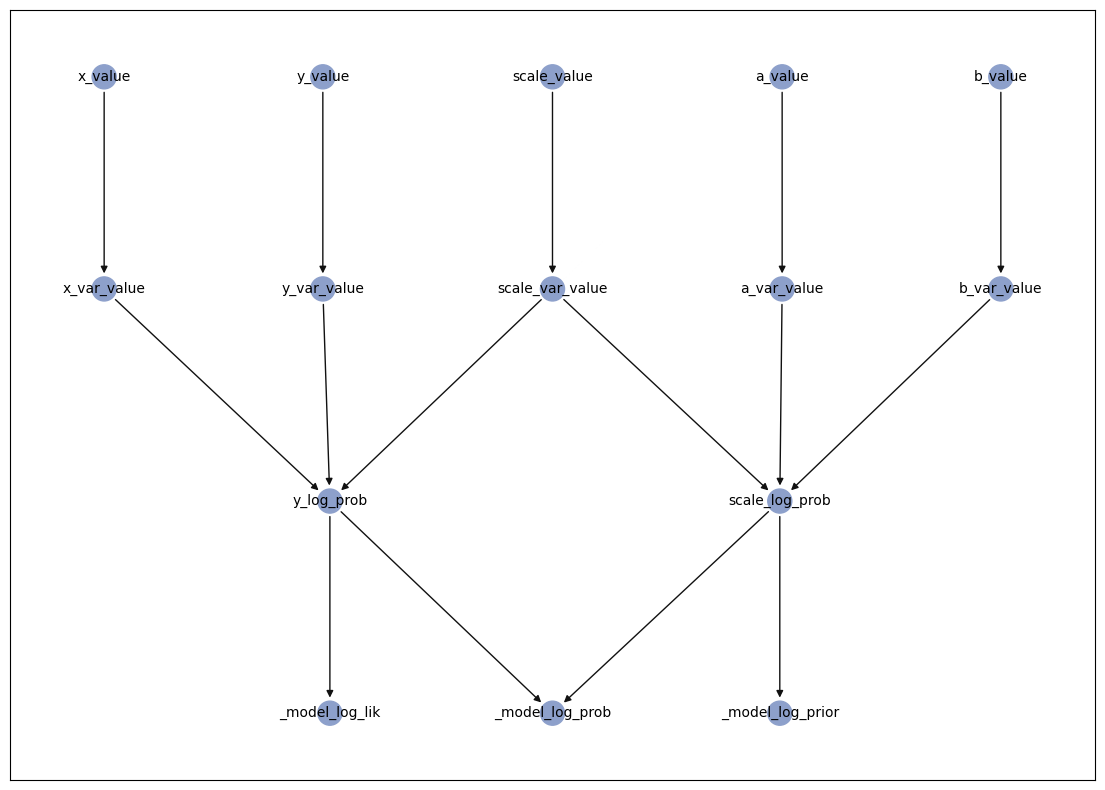

In [18]:
model.plot_nodes()

## Replace value node with unnamed node, that node's name is updated

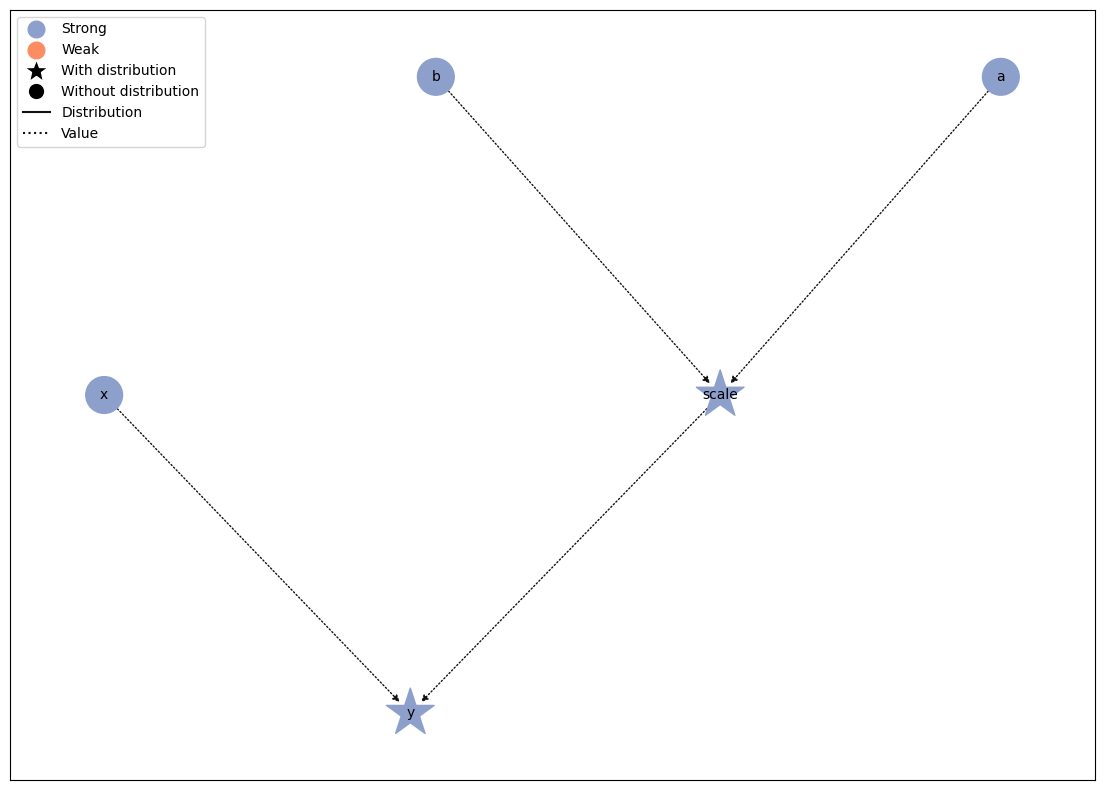

In [19]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

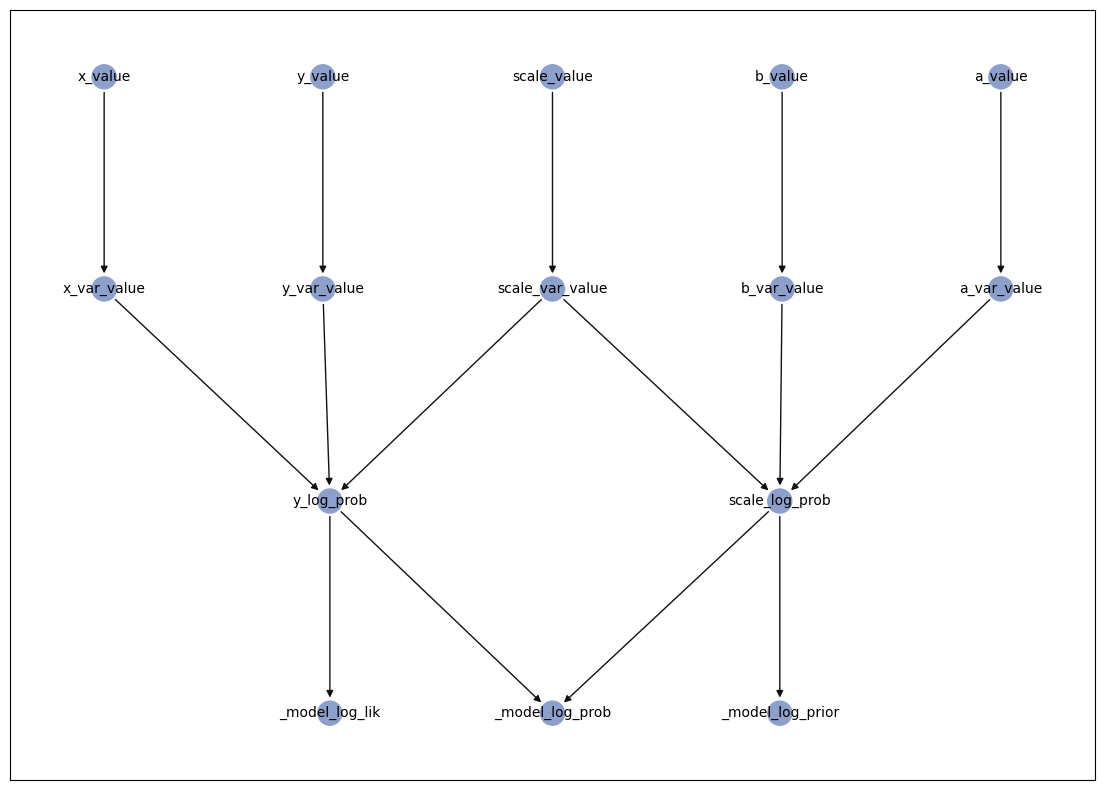

In [20]:
scale.value_node = lsl.Value(2.0)
model.plot_nodes()

In [21]:
scale.value

Array(2., dtype=float32, weak_type=True)

## Replace value node with named node, that node's name is not updated

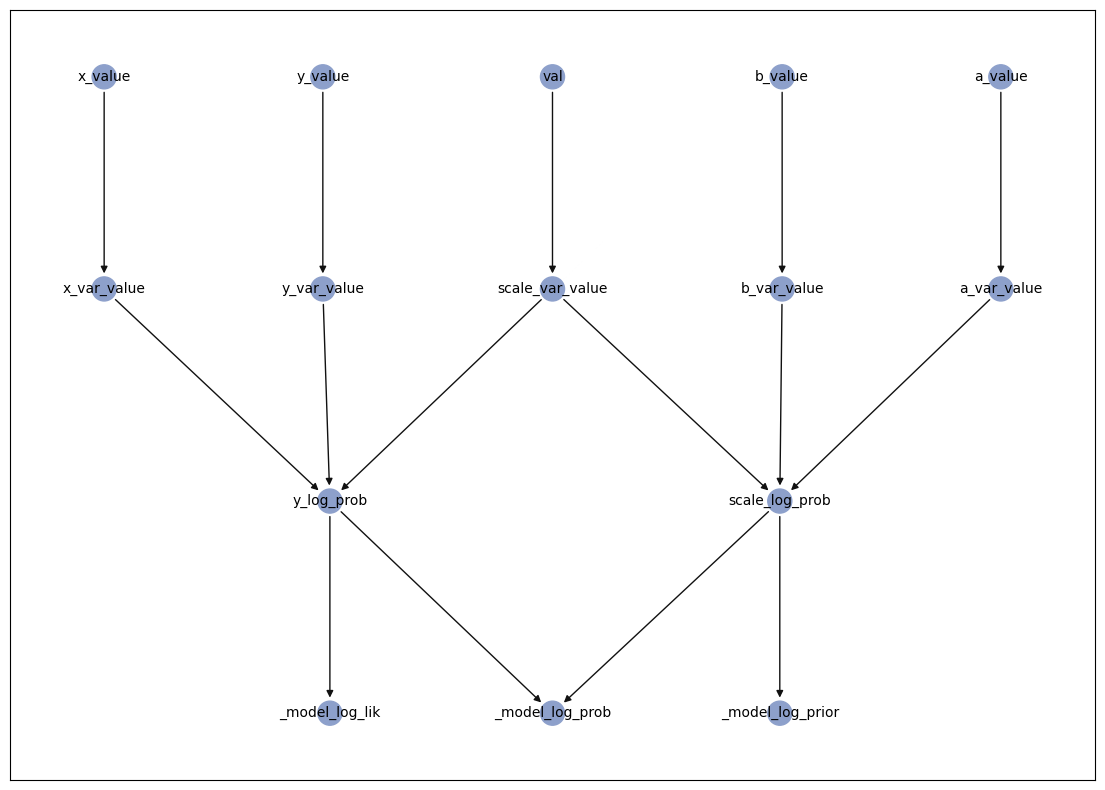

In [22]:
scale.value_node = lsl.Value(2.0, _name="val")
model.plot_nodes()

## Replace value node with float

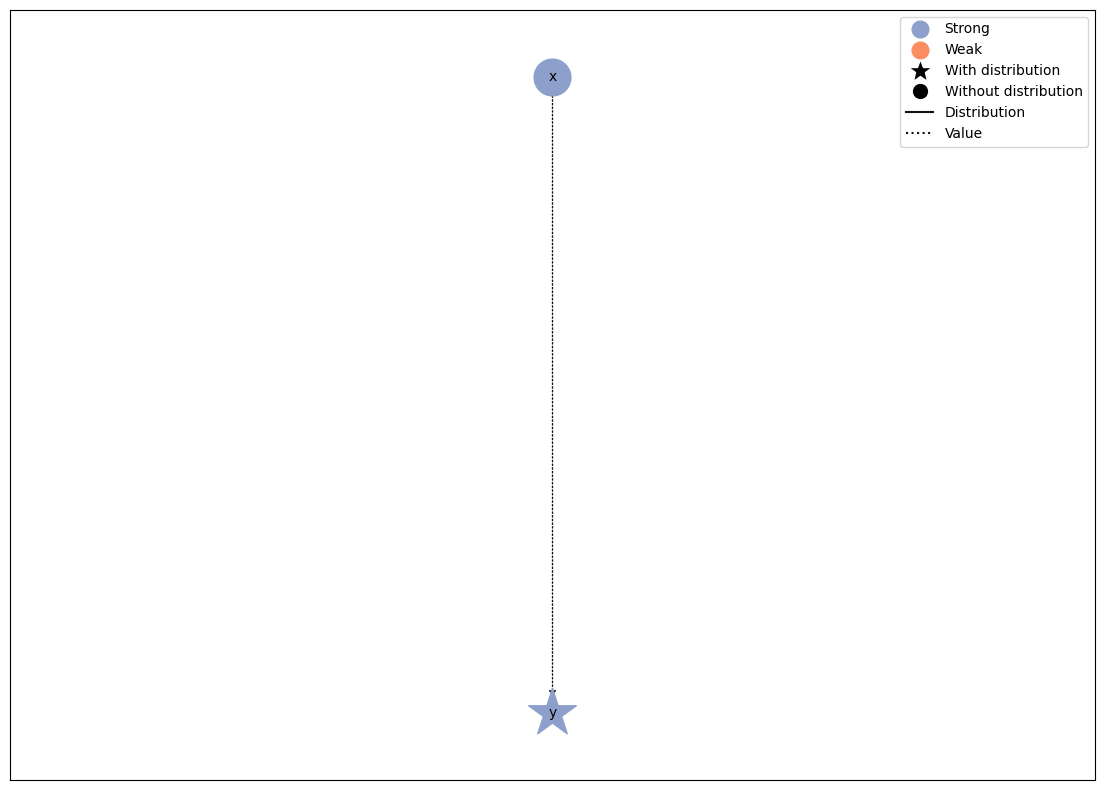

In [23]:
model.replace(scale, 1.0)
model.plot_vars()

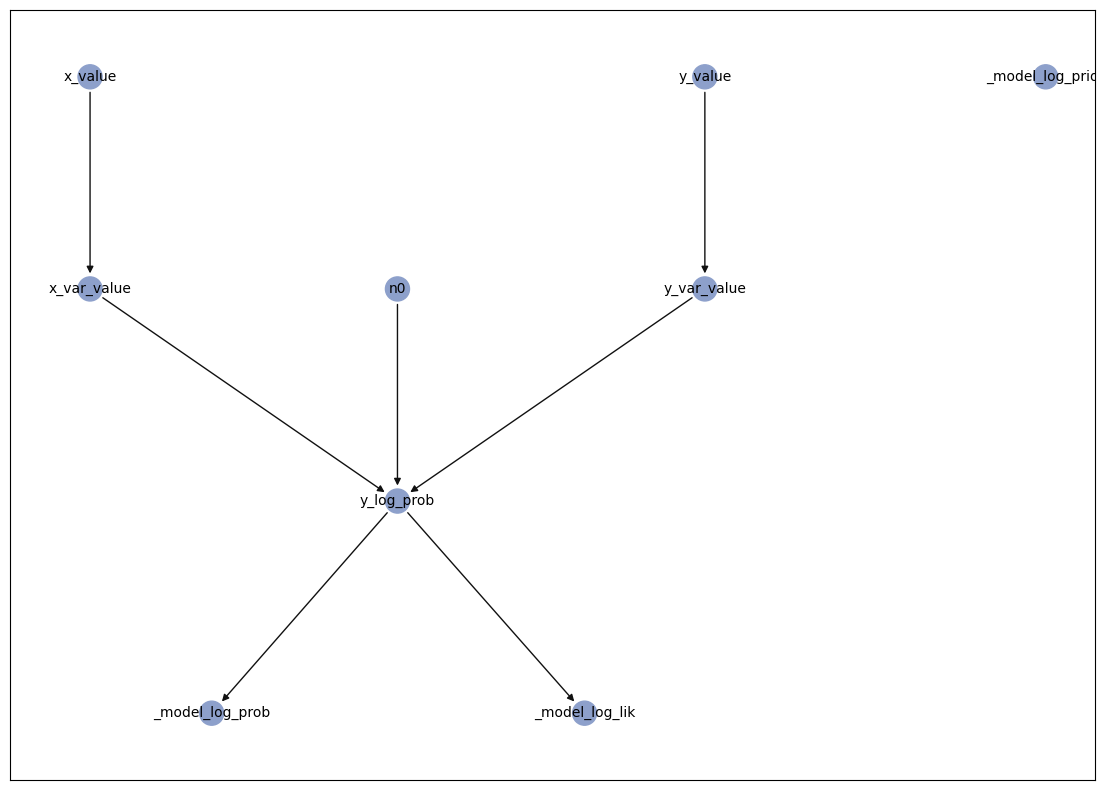

In [24]:
model.plot_nodes()

## Apply Var.biject

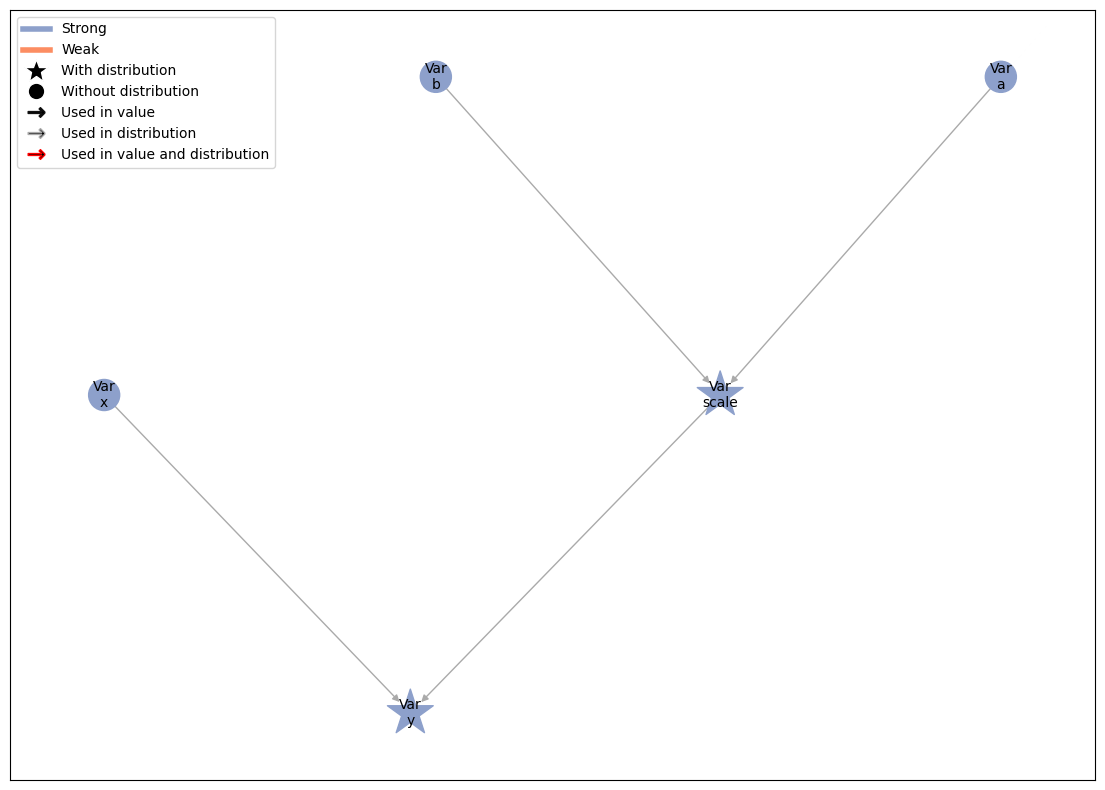

In [20]:
import tensorflow_probability.substrates.jax.bijectors as tfb

x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)
y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

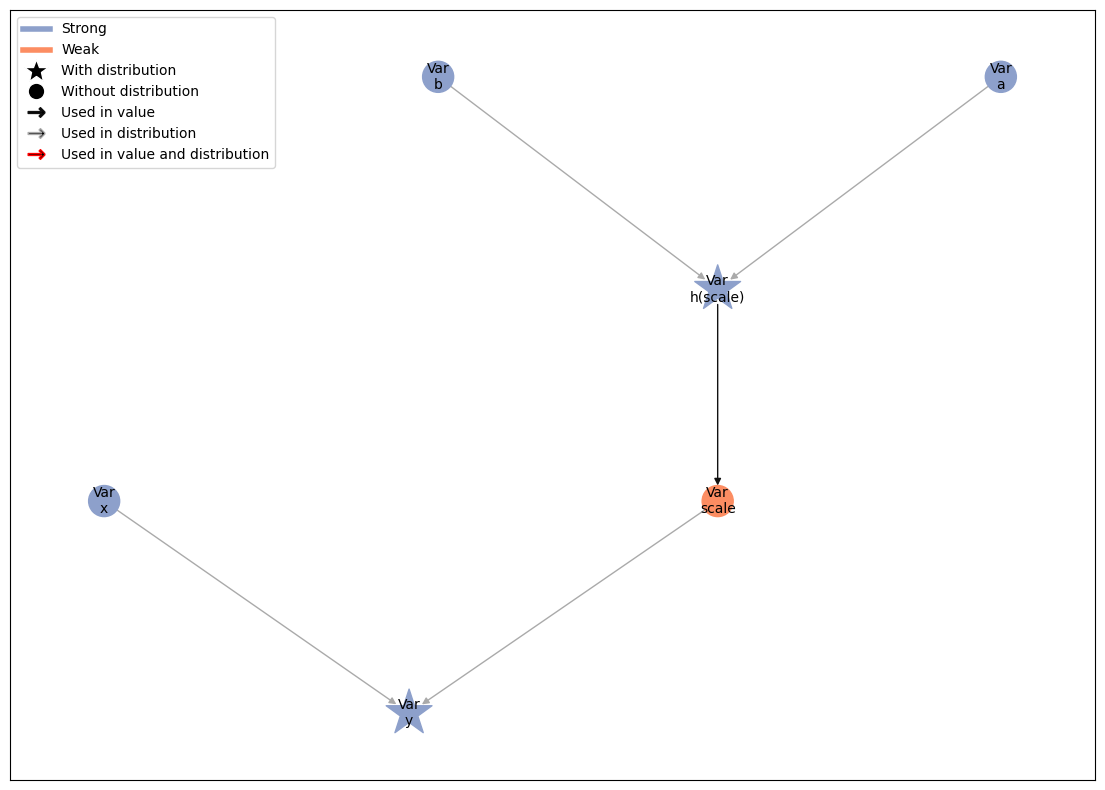

In [21]:
scale.biject(tfb.Exp())
model.plot_vars()